In [1]:
import sys
sys.path.append('../')

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from helpers.cm26 import DatasetCM26, read_datasets
from helpers.selectors import *
from helpers.operators import Coarsen, Filtering, Subsampling, CoarsenKochkov, CoarsenWeighted, CoarsenKochkovMinMax
from helpers.state_functions import *

import hvplot
import cmocean

%load_ext autoreload
%autoreload 3

In [169]:
ds = read_datasets(['validate'], [15], 'subfilter-large')['validate-15']

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15


In [170]:
ds2d = ds.select2d(time=5, zl=5)

In [3]:
EXP1 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/EXP1/model/Tall.nc')

In [171]:
ann1 = ds2d.state.Apply_ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])

In [172]:
ann2 = ds.state.ANN_inference(ann_Tall=EXP1, gradient_features=['sh_xy', 'sh_xx', 'rel_vort'], zl=5, time=5)

In [173]:
def norm(x):
    return torch.max(torch.abs(x))

In [174]:
norm(ann1['Txx'] - ann2['Txx'])

tensor(1.1176e-08, grad_fn=<MaxBackward1>)

In [175]:
norm(ann1['Tyy'] - ann2['Tyy'])

tensor(1.1176e-08, grad_fn=<MaxBackward1>)

In [176]:
norm(ann1['Txy'] - ann2['Txy'])

tensor(3.8417e-09, grad_fn=<MaxBackward1>)

In [10]:
%time ann1 = ds2d.state.Apply_ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])

CPU times: user 61.8 ms, sys: 5.79 ms, total: 67.6 ms
Wall time: 5.8 ms


In [11]:
%time ann2 = ds.state.ANN_inference(ann_Tall=EXP1, gradient_features=['sh_xy', 'sh_xx', 'rel_vort'], zl=5, time=5)

CPU times: user 344 ms, sys: 5.98 ms, total: 350 ms
Wall time: 42.9 ms


In [12]:
%%time
for zl in range(10):
    for time in range(12):
        ds2d = ds.select2d(time=time, zl=zl)
        ann1 = ds2d.state.Apply_ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])

CPU times: user 1min 30s, sys: 504 ms, total: 1min 30s
Wall time: 27.8 s


In [18]:
%%time
for zl in range(10):
    for time in range(12):
        ann2 = ds.state.ANN_inference(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'],zl=zl, time=time)

CPU times: user 18.9 s, sys: 50.7 ms, total: 18.9 s
Wall time: 1.37 s


In [14]:
%%time
ds2d = ds.select2d(time=0, zl=0)
for zl in range(10):
    for time in range(12):
        ann1 = ds2d.state.Apply_ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])

CPU times: user 8.06 s, sys: 40.3 ms, total: 8.1 s
Wall time: 760 ms


In [16]:
%%time
for zl in range(10):
    for time in range(12):
        ann2 = ds.state.ANN_inference(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'],zl=0, time=0)

CPU times: user 18.6 s, sys: 32.6 ms, total: 18.7 s
Wall time: 1.38 s


In [177]:
import itertools

In [178]:
rots  = [90, 0]
refxs = [True, False]
refys = [True, False]

In [179]:
%%time
ds2d = ds.select2d(time=np.random.randint(12), zl=np.random.randint(8))
for rotation, reflect_x, reflect_y in itertools.product(rots, refxs, refys):
    ann1 = ds2d.state.Apply_ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'], rotation=rotation, reflect_x=reflect_x, reflect_y=reflect_y)

CPU times: user 1.18 s, sys: 35.8 ms, total: 1.22 s
Wall time: 273 ms


In [180]:
%%time
time=np.random.randint(12); zl=np.random.randint(8)
for rotation, reflect_x, reflect_y in itertools.product(rots, refxs, refys):
    ann2 = ds.state.ANN_inference(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'],
                                  zl=zl, time=time, rotation=rotation, reflect_x=reflect_x, reflect_y=reflect_y)

CPU times: user 1.47 s, sys: 18.2 ms, total: 1.49 s
Wall time: 110 ms


In [181]:
from helpers.ann_tools import tensor_from_xarray

In [182]:
%%time
time=np.random.randint(12); zl=np.random.randint(8)

wet = tensor_from_xarray(ds.param.wet.isel(zl=zl))
areaT = tensor_from_xarray(ds.param.dxT * ds.param.dyT)
sh_xy_h = tensor_from_xarray(ds.data.sh_xy_h.isel(zl=zl, time=time))
sh_xx = tensor_from_xarray(ds.data.sh_xx.isel(zl=zl, time=time))
rel_vort_h = tensor_from_xarray(ds.data.rel_vort_h.isel(zl=zl, time=time))

for rotation, reflect_x, reflect_y in itertools.product(rots, refxs, refys):
    ann2 = ds.state.ANN_inference(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'],
                                  rotation=rotation, reflect_x=reflect_x, reflect_y=reflect_y,
                                  data = {'sh_xy_h': sh_xy_h, 'sh_xx': sh_xx, 'rel_vort_h': rel_vort_h, 'areaT': areaT, 'wet': wet})

CPU times: user 507 ms, sys: 14.8 ms, total: 522 ms
Wall time: 39.3 ms


In [183]:
ann2 = ds.state.ANN_inference(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'],
                                  rotation=rotation, reflect_x=reflect_x, reflect_y=reflect_y,
                                  data = {'sh_xy_h': sh_xy_h, 'sh_xx': sh_xx, 'rel_vort_h': rel_vort_h, 'areaT': areaT, 'wet': wet})

In [188]:
ds2d = ds.select2d(time=time, zl=zl)
ann1 = ds2d.state.Apply_ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'], rotation=rotation, reflect_x=reflect_x, reflect_y=reflect_y)

In [189]:
norm(ann1['Txx'] - ann2['Txx'])

tensor(4.4703e-08, grad_fn=<MaxBackward1>)

In [190]:
norm(ann1['Tyy'] - ann2['Tyy'])

tensor(2.3283e-08, grad_fn=<MaxBackward1>)

In [191]:
norm(ann1['Txy'] - ann2['Txy'])

tensor(2.2352e-08, grad_fn=<MaxBackward1>)

# Comparing training algorithm speed

In [193]:
from helpers.train_ann_fluxes import train_ANN_fluxes

In [195]:
from helpers.train_ann import train_ANN

In [203]:
train_ANN(symmetries='All')

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Factor: 15, depth: 0, MSE train/validate: [1.218841, 4.868810], dEdt error: train/validate [0.429748, 0.298240]
Factor: 12, depth: 0, MSE train/validate: [4.005307, 1.466033], dEdt error: train/validate [0.448405, 0.699044]
Iter/num_iters [1/10]. Iter time/Remaining time in seconds: [1.80/16.2]
Factor: 15, depth: 0, MSE train/validate: [1.794054, 1.167430], dEdt error: train/validate [0.904119, 0.745485]
Factor: 12, depth: 0, MSE train/validate: [1.627098, 1.670481], dEdt error: train/validate [0.632476, 0.820185]
Iter/num_iters [2/10]. Iter time/Remaining time in seconds: [1.62/13.7]
Factor: 15, depth: 0, MSE train/validate: [1.680863, 1.046263], 

(None,
 None,
 ANN(
   (layers): Sequential(
     (0): Linear(in_features=27, out_features=20, bias=True)
     (1): Linear(in_features=20, out_features=3, bias=True)
   )
 ),
 <xarray.Dataset> Size: 1kB
 Dimensions:              (factor: 2, depth: 1, iter: 10)
 Coordinates:
   * factor               (factor) int64 16B 12 15
   * depth                (depth) int64 8B 0
 Dimensions without coordinates: iter
 Data variables:
     MSE_train            (iter, factor, depth) float64 160B 4.005 ... 0.9872
     MSE_plain_waves      (iter, factor, depth) float64 160B 0.0 0.0 ... 0.0 0.0
     MSE_short_zero       (iter, factor, depth) float64 160B 0.0 0.0 ... 0.0 0.0
     MSE_jacobian_trace   (iter, factor, depth) float64 160B 0.0 0.0 ... 0.0 0.0
     MSE_validate         (iter, factor, depth) float64 160B 1.466 ... 0.9755
     MSE_perturbed        (iter, factor, depth) float64 160B 0.0 0.0 ... 0.0 0.0
     dEdt_error           (iter, factor, depth) float64 160B 0.4484 ... 0.5614
     dEdt_error

In [204]:
train_ANN_fluxes(symmetries='All')

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Factor: 15, depth: 0, MSE train/validate: [1.733165, 1.623097]
Factor: 12, depth: 0, MSE train/validate: [1.858104, 1.640639]
Iter/num_iters [1/10]. Iter time/Remaining time in seconds: [0.40/3.6]
Factor: 15, depth: 0, MSE train/validate: [1.255478, 1.280911]
Factor: 12, depth: 0, MSE train/validate: [1.724724, 1.352721]
Iter/num_iters [2/10]. Iter time/Remaining time in seconds: [0.40/3.2]
Factor: 12, depth: 0, MSE train/validate: [1.381539, 1.015741]
Factor: 15, depth: 0, MSE train/validate: [0.934835, 0.913363]
Iter/num_iters [3/10]. Iter time/Remaining time in seconds: [0.37/2.7]
Factor: 12, depth: 0, MSE train/validate: [1.153960, 1.000768]
Fa

(ANN(
   (layers): Sequential(
     (0): Linear(in_features=27, out_features=20, bias=True)
     (1): Linear(in_features=20, out_features=3, bias=True)
   )
 ),
 <xarray.Dataset> Size: 344B
 Dimensions:       (factor: 2, depth: 1, iter: 10)
 Coordinates:
   * factor        (factor) int64 16B 12 15
   * depth         (depth) int64 8B 0
 Dimensions without coordinates: iter
 Data variables:
     MSE_train     (iter, factor, depth) float64 160B 1.858 1.733 ... 0.6552
     MSE_validate  (iter, factor, depth) float64 160B 1.641 1.623 ... 0.6599)

# Bigger training example

In [67]:
from helpers.train_ann_fluxes import train_ANN_fluxes
ann_Tall, logger = train_ANN_fluxes(factors = [4,9,12,15], symmetries='All', time_iters=20, depth_idx=np.arange(10))

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Factor: 15, depth: 9, MSE train/validate: [2.566948, 2.930540]
Factor: 4, depth: 5, MSE train/validate: [17.487310, 15.442478]
Factor: 4, depth: 1, MSE train/validate: [12.262527, 11.479742]
Factor: 15, depth: 6, MSE train/validate: [1.636528, 1.508087]
Factor: 12, depth: 7, MSE train/validate: [1.896319, 2.023772]

KeyboardInterrupt: 

In [36]:
ann_Tall_sym_true, logger_sym_true = train_ANN_fluxes(factors = [4,9,12,15], symmetries='True', time_iters=20, depth_idx=np.arange(10))

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Factor: 15, depth: 0, MSE train/validate: [2.928522, 2.914344]
Factor: 4, depth: 1, MSE train/validate: [19.800678, 18.583853]
Factor: 12, depth: 7, MSE train/validate: [2.077443, 1.999471]
Factor: 12, depth: 8, MSE train/validate: [2.309435, 2.121545]
Factor: 12, depth: 3, MSE train/validate: [2.614864, 2.009100]


In [42]:
ann_Tall_sym_true_long, logger_sym_true_long = train_ANN_fluxes(factors = [4,9,12,15], symmetries='True', time_iters=20*8, depth_idx=np.arange(10))

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Factor: 4, depth: 9, MSE train/validate: [6.186961, 5.876370]
Factor: 4, depth: 2, MSE train/validate: [7.876769, 7.121691]
Factor: 15, depth: 9, MSE train/validate: [1.534247, 1.375319]
Factor: 9, depth: 0, MSE train/validate: [2.532983, 2.839664]
Factor: 9, depth: 7, MSE train/validate: [2.213734, 2.030269]
Facto

In [49]:
ann_Tall_sym_false, logger_sym_false = train_ANN_fluxes(factors = [4,9,12,15], symmetries='False', time_iters=20*8, depth_idx=np.arange(10))

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15
Factor: 4, depth: 5, MSE train/validate: [12.030317, 11.123335]
Factor: 4, depth: 4, MSE train/validate: [10.820331, 10.332124]
Factor: 4, depth: 6, MSE train/validate: [10.432817, 9.189930]
Factor: 15, depth: 2, MSE train/validate: [1.756777, 1.865153]
Factor: 15, depth: 6, MSE train/validate: [1.457252, 1.559732]

In [14]:
ds = read_datasets(['test'], [4], 'subfilter-large')['test-4']

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4


In [15]:
ds2d = ds.select2d(time=5, zl=5)

In [24]:
EXP1 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/EXP1/model/Tall.nc')
ann1 = ds2d.state.ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
ann_new = ds2d.state.ANN(ann_Tall=ann_Tall,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
mask = ds2d.data.wet_nan

Correlation: 0.8762117999052491
Relative Error: 0.3639641075525854
R2 =  0.818712372938561
R2 max =  0.8230101454422373
Optinal scaling: 0.9326065689674863
Nans [test/control]: [13219, 13219]


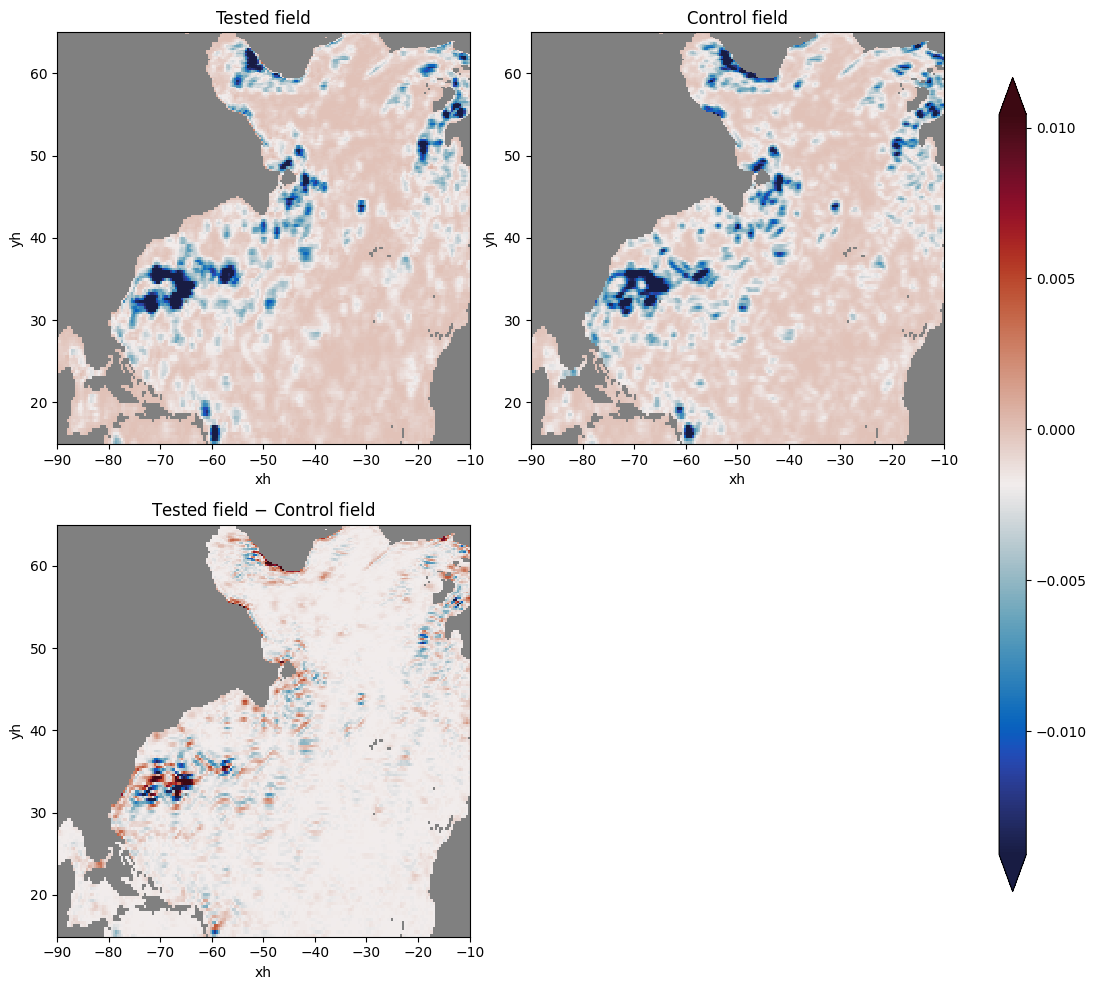

In [25]:
compare(ann1['Txx'] * mask,ds2d.data.Txx * mask);

Correlation: 0.9296564816806604
Relative Error: 0.36175159370732307
R2 =  0.8420853141759247
R2 max =  0.8981648954952945
Optinal scaling: 0.8000794491631515
Nans [test/control]: [13219, 13219]


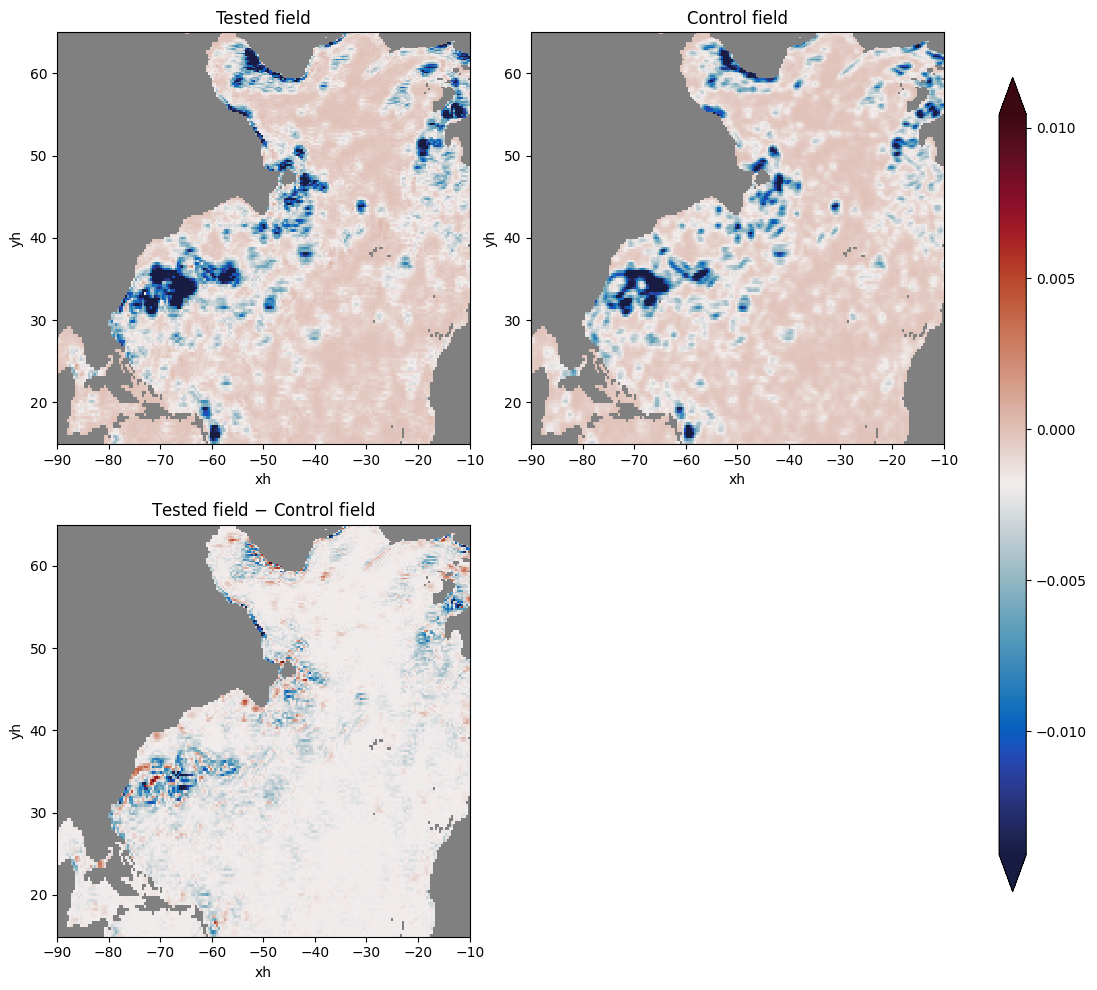

In [26]:
compare(ann_new['Txx'] * mask,ds2d.data.Txx * mask);

Correlation: 0.8942614732786851
Relative Error: 0.4884598402251417
R2 =  0.7674100989362267
R2 max =  0.7997297548717773
Optinal scaling: 0.8326183930765436
Nans [test/control]: [13219, 13219]


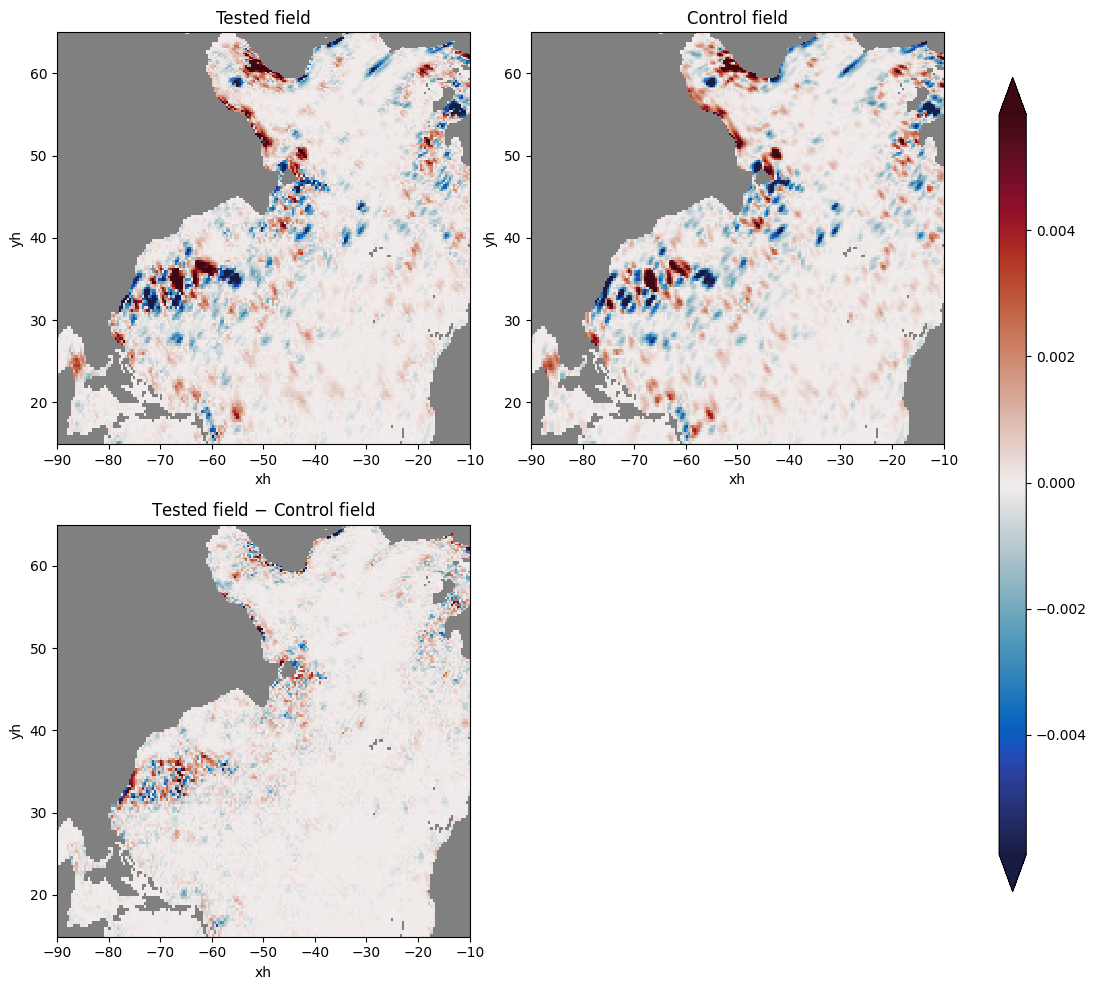

In [27]:
compare(ann_new['Txy'] * mask,ds2d.data.Txy * mask);

Correlation: 0.8278233424915556
Relative Error: 0.6084251950561611
R2 =  0.6576686186585401
R2 max =  0.6848469352902451
Optinal scaling: 0.8338812284566405
Nans [test/control]: [13219, 13219]


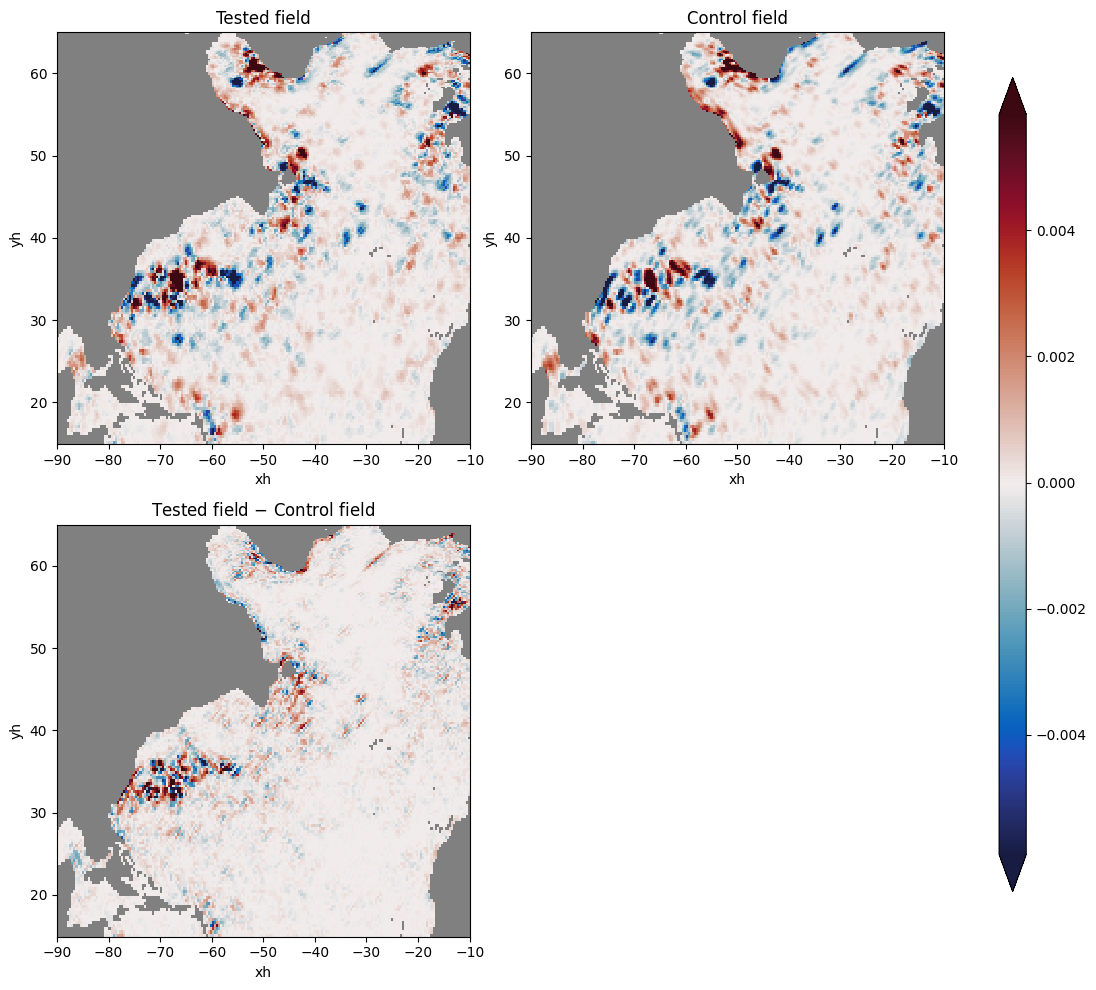

In [28]:
compare(ann1['Txy'] * mask,ds2d.data.Txy * mask);

Correlation: 0.9140354457762937
Relative Error: 0.3253529435828395
R2 =  0.8704227268155723
R2 max =  0.8723541302486431
Optinal scaling: 0.9550612169133073
Nans [test/control]: [13219, 13219]


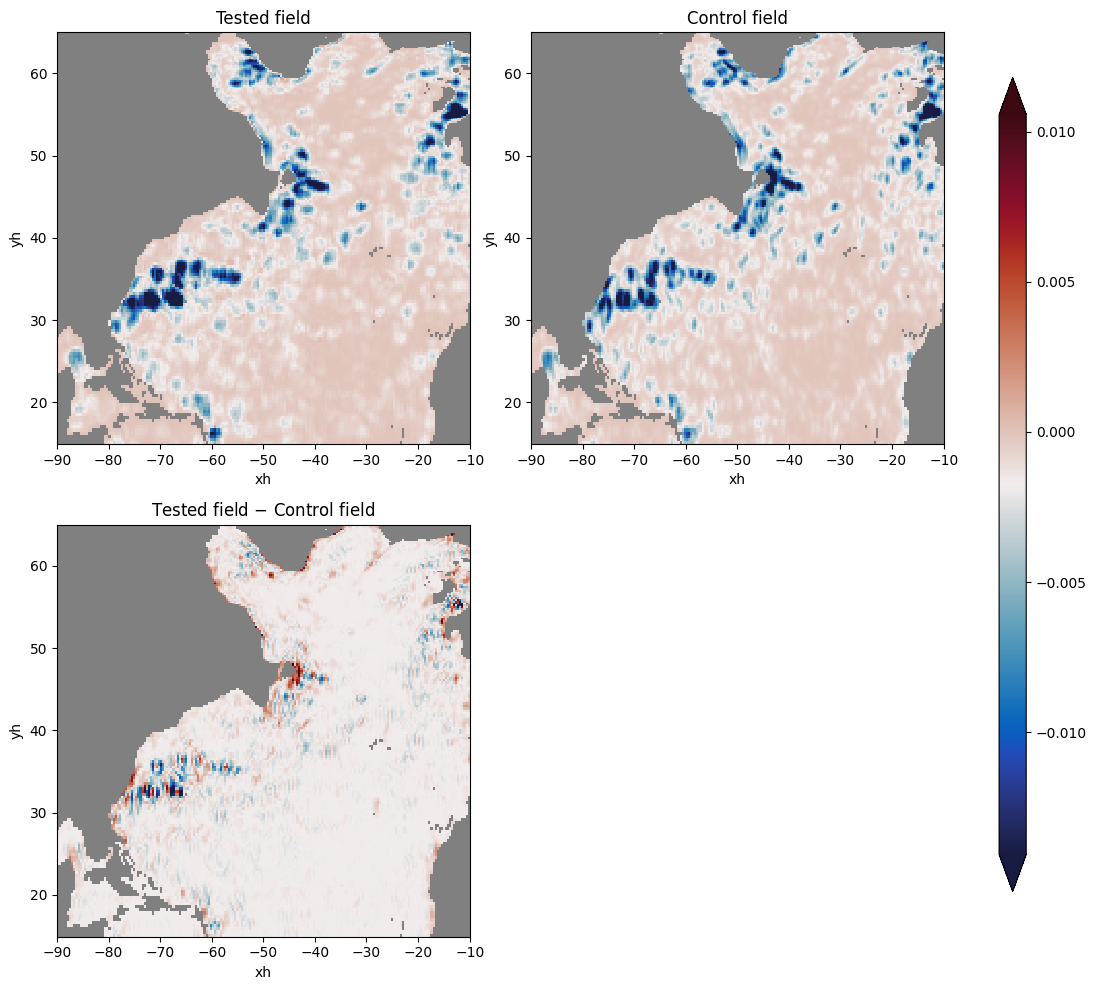

In [29]:
compare(ann1['Tyy'] * mask,ds2d.data.Tyy * mask);

Correlation: 0.9311234247839095
Relative Error: 0.27806810867801274
R2 =  0.8816496684878137
R2 max =  0.8963735751705332
Optinal scaling: 1.1470050816182222
Nans [test/control]: [13219, 13219]


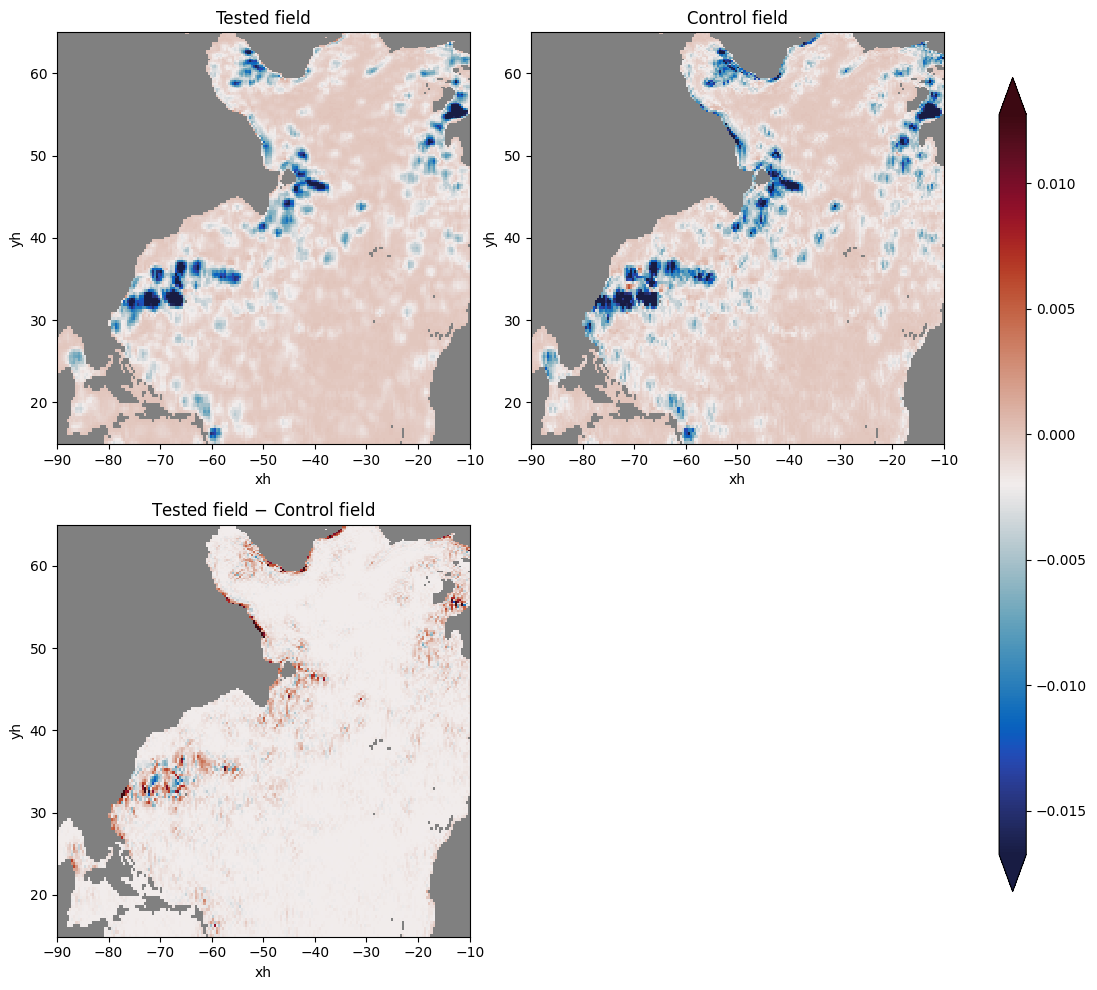

In [30]:
compare(ann1['Tyy'] * mask,ann_new['Tyy'] * mask);

In [53]:
logger.to_netcdf('loggers/logger_all.nc')

In [54]:
logger_sym_true_long.to_netcdf('loggers/logger_true.nc')

In [56]:
logger_sym_false.to_netcdf('loggers/logger_false.nc')

In [68]:
logger = xr.open_dataset('loggers/logger_all.nc')

In [69]:
logger_sym_true_long = xr.open_dataset('loggers/logger_true.nc')

In [70]:
logger_sym_false = xr.open_dataset('loggers/logger_false.nc')

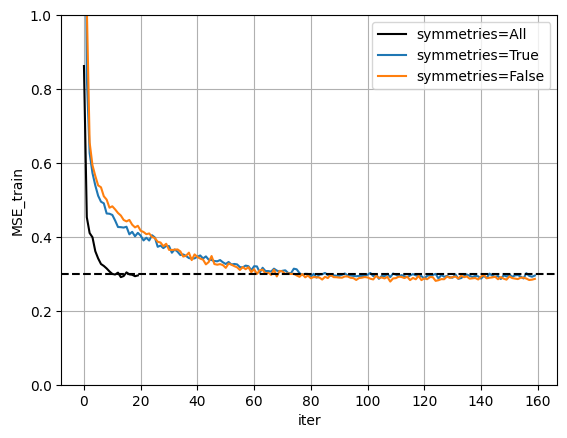

In [75]:
logger.MSE_train.mean(['factor', 'depth']).plot(color='k', label='symmetries=All')
logger_sym_true_long.MSE_train.mean(['factor', 'depth']).plot(label='symmetries=True')
logger_sym_false.MSE_train.mean(['factor', 'depth']).plot(label='symmetries=False')
plt.axhline(y=0.3, color='k', ls='--')
plt.ylim([0,1])
plt.grid()
plt.legend()

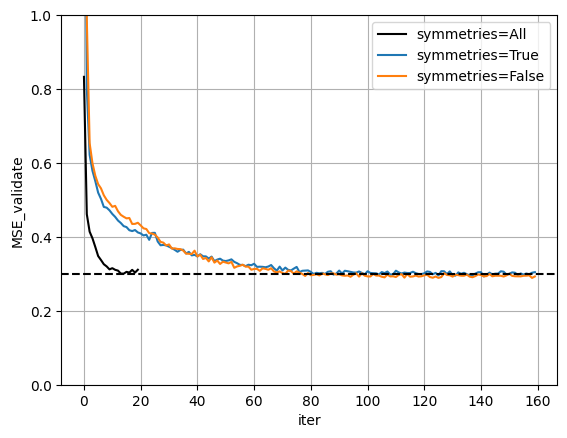

In [74]:
logger.MSE_validate.mean(['factor', 'depth']).plot(color='k', label='symmetries=All')
#logger_sym_true.MSE_train.mean(['factor', 'depth']).plot()
logger_sym_true_long.MSE_validate.mean(['factor', 'depth']).plot(label='symmetries=True')
logger_sym_false.MSE_validate.mean(['factor', 'depth']).plot(label='symmetries=False')
plt.axhline(y=0.3, color='k', ls='--')
plt.ylim([0,1])
plt.grid()
plt.legend()

# New testing

In [4]:
ds = read_datasets(['validate'], [15], subfilter='subfilter-large', FGR=3)

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15


In [51]:
%time skill = ds[f'validate-15'].predict_ANN(None, None, EXP1, stencil_size=3, dimensional_scaling=True, gradient_features=['sh_xy', 'sh_xx', 'rel_vort']).SGS_skill()

CPU times: user 4min, sys: 3.21 s, total: 4min 3s
Wall time: 1min 33s


In [7]:
skill.R2.mean()

<xarray.DataArray 'R2' ()> Size: 4B
array(0.31090063, dtype=float32)

In [8]:
skill.R2T.mean()

<xarray.DataArray 'R2T' ()> Size: 4B
array(0.46221143, dtype=float32)

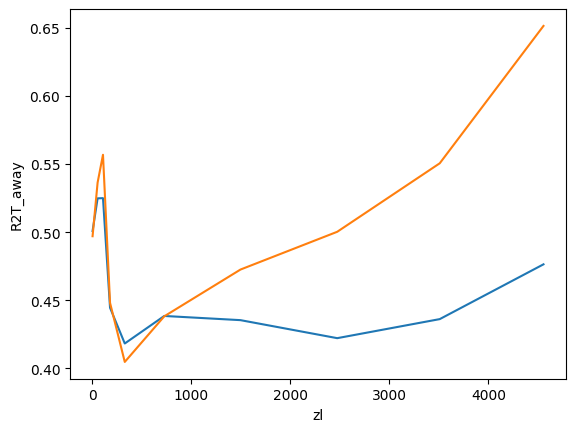

In [9]:
skill.R2T.plot()
skill.R2T_away.plot()

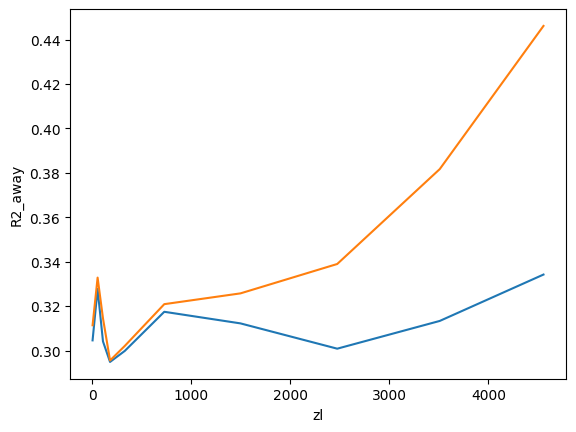

In [10]:
skill.R2.plot()
skill.R2_away.plot()

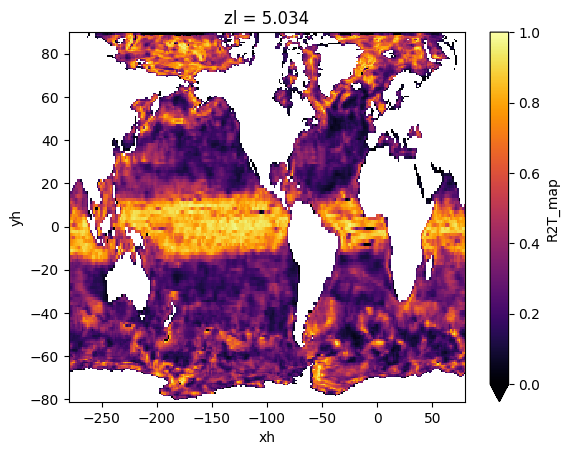

In [43]:
skill.R2T_map.isel(zl=0).plot(vmin=0, vmax=1, cmap='inferno')

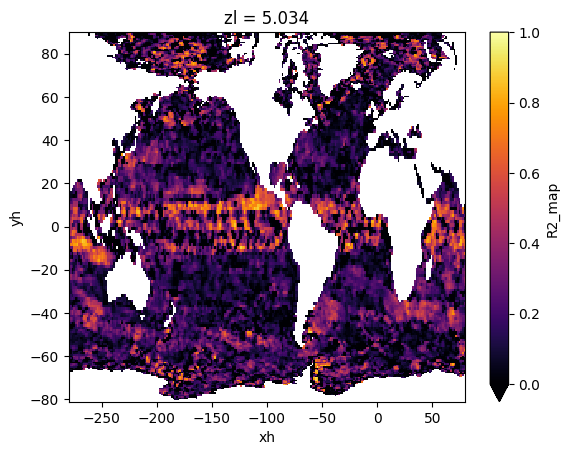

In [44]:
skill.R2_map.isel(zl=0).plot(vmin=0, vmax=1, cmap='inferno')

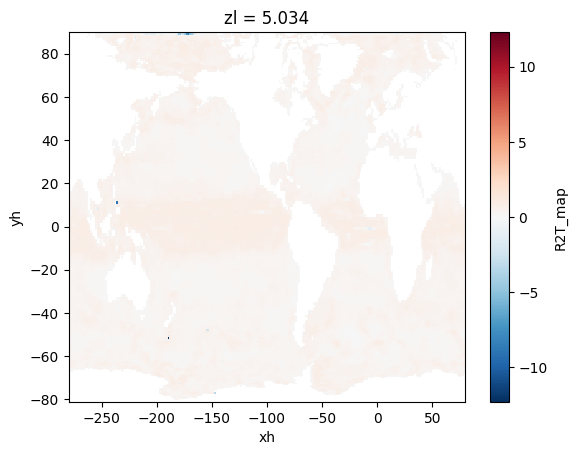

In [14]:
skill.R2T_map.isel(zl=0).plot()

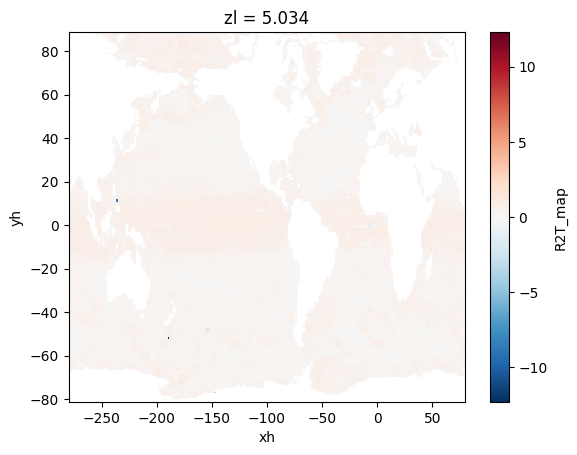

In [17]:
skill.R2T_map.isel(zl=0,yh=slice(None,-2)).plot()

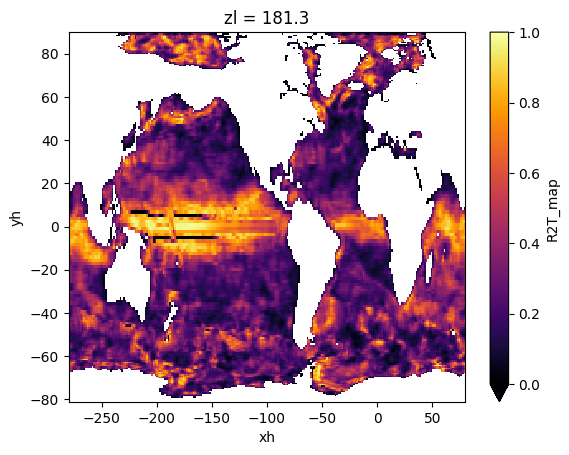

In [45]:
skill.R2T_map.isel(zl=3).plot(vmin=0, vmax=1, cmap='inferno')

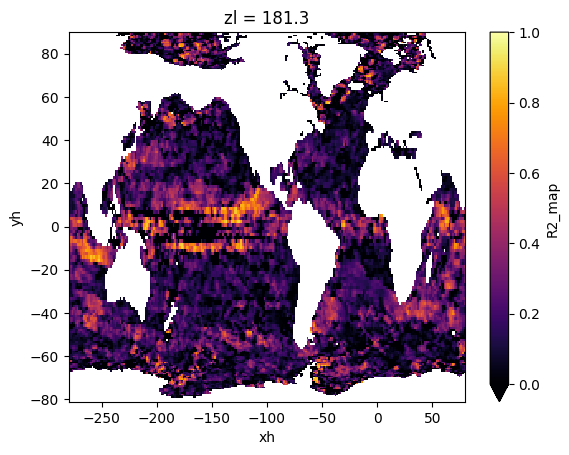

In [46]:
skill.R2_map.isel(zl=3).plot(vmin=0, vmax=1, cmap='inferno')

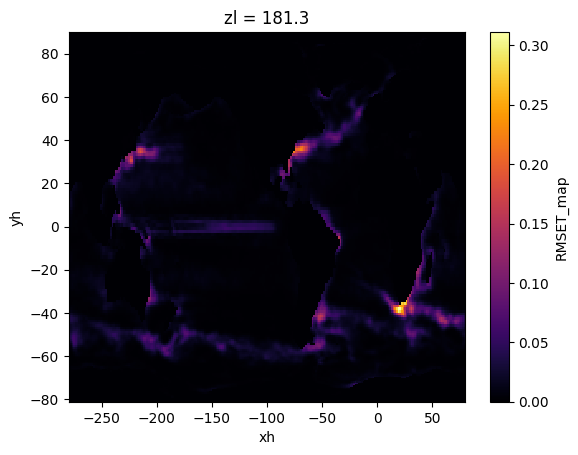

In [48]:
skill.RMSET_map.isel(zl=3).plot(cmap='inferno')

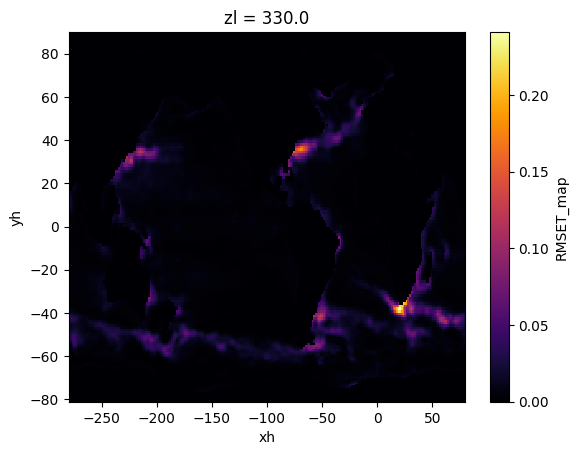

In [50]:
skill.RMSET_map.isel(zl=4).plot(cmap='inferno')

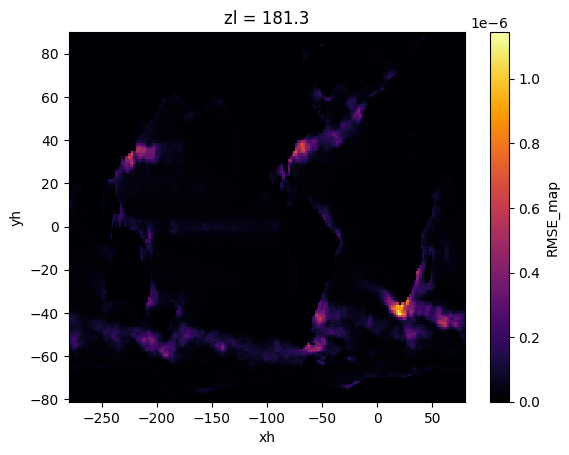

In [49]:
skill.RMSE_map.isel(zl=3).plot(cmap='inferno')

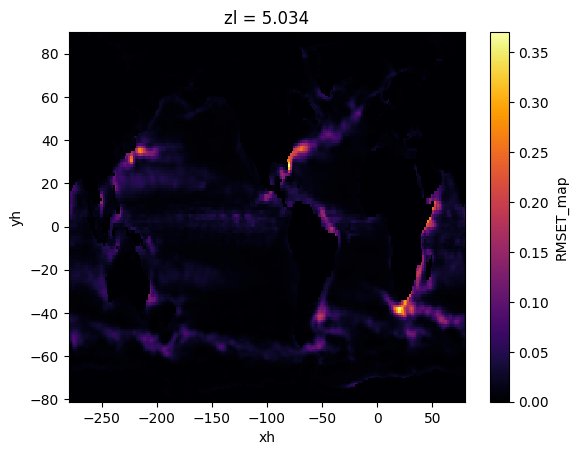

In [52]:
skill.RMSET_map.isel(zl=0).plot(cmap='inferno')

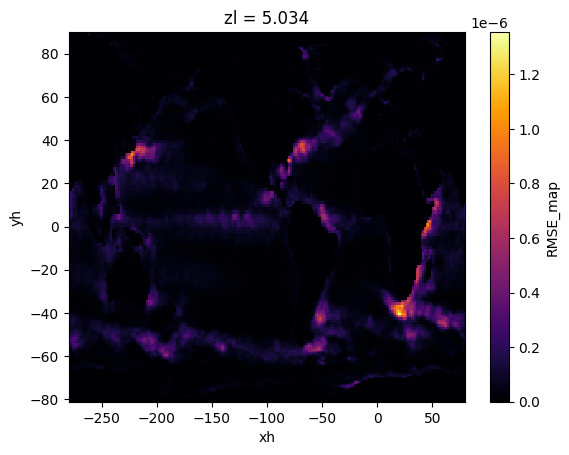

In [53]:
skill.RMSE_map.isel(zl=0).plot(cmap='inferno')

Correlation: 0.4964057207107544
Relative Error: 0.8945192694664001
R2 =  0.17251724004745483
R2 max =  0.24572670459747314
Optinal scaling: 0.6469014883041382
Nans [test/control]: [0, 0]


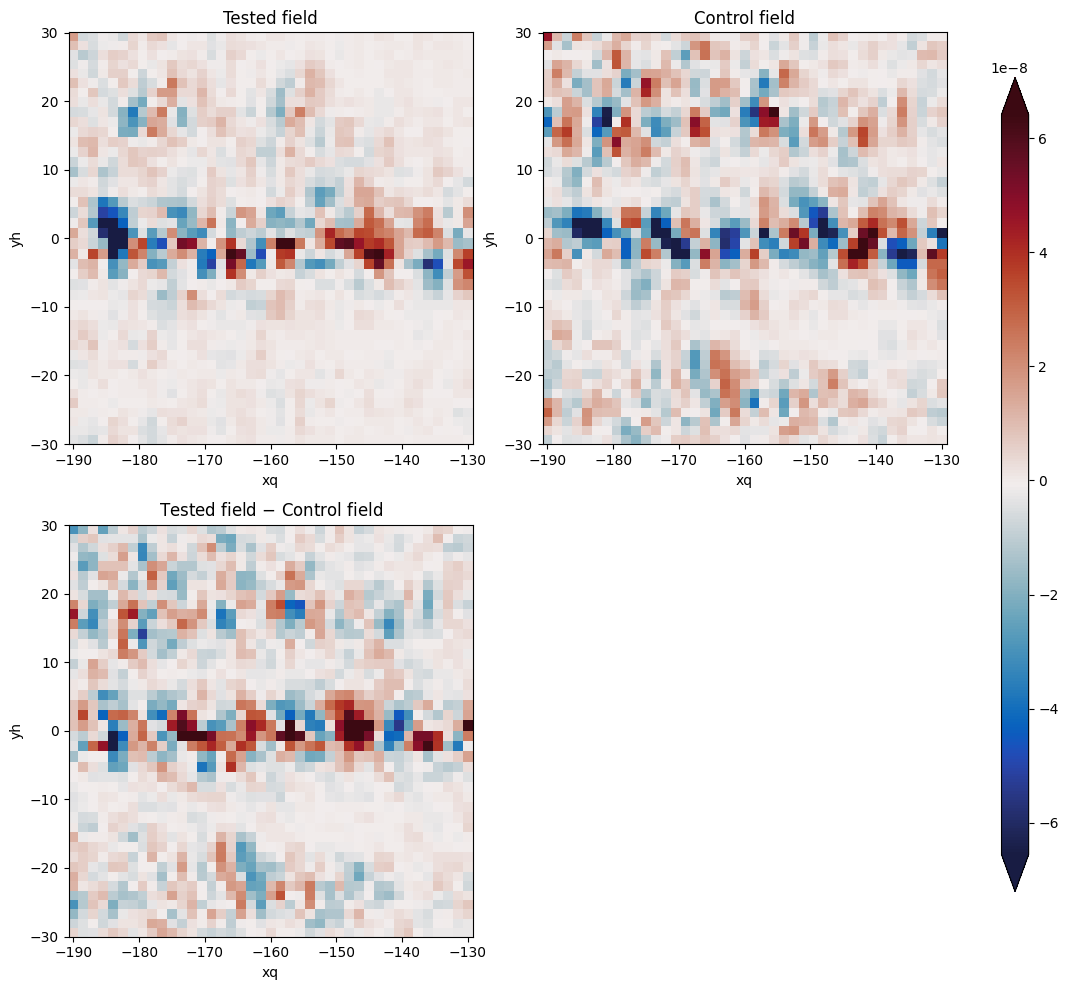

In [55]:
compare(skill.ZB20u.isel(zl=3), skill.SGSx.isel(zl=3),selector=select_Equator);

Correlation: 0.5427277088165283
Relative Error: 0.9358758926391602
R2 =  0.18314218521118164
R2 max =  0.2945546507835388
Optinal scaling: 0.6191900968551636
Nans [test/control]: [0, 0]


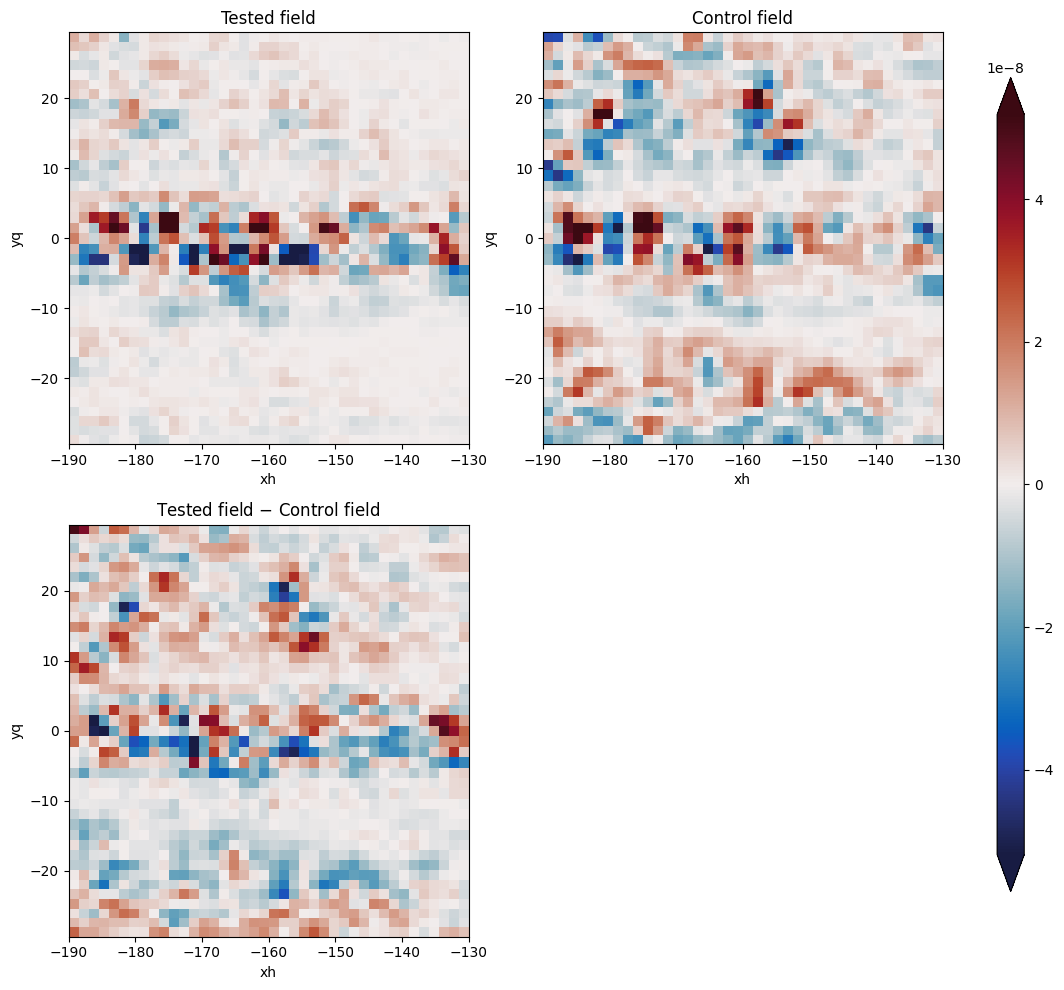

In [56]:
compare(skill.ZB20v.isel(zl=3), skill.SGSy.isel(zl=3),selector=select_Equator);

Correlation: 0.770896852016449
Relative Error: 0.7349061369895935
R2 =  0.4484955072402954
R2 max =  0.617886871099472
Optinal scaling: 2.0990312099456787
Nans [test/control]: [0, 0]


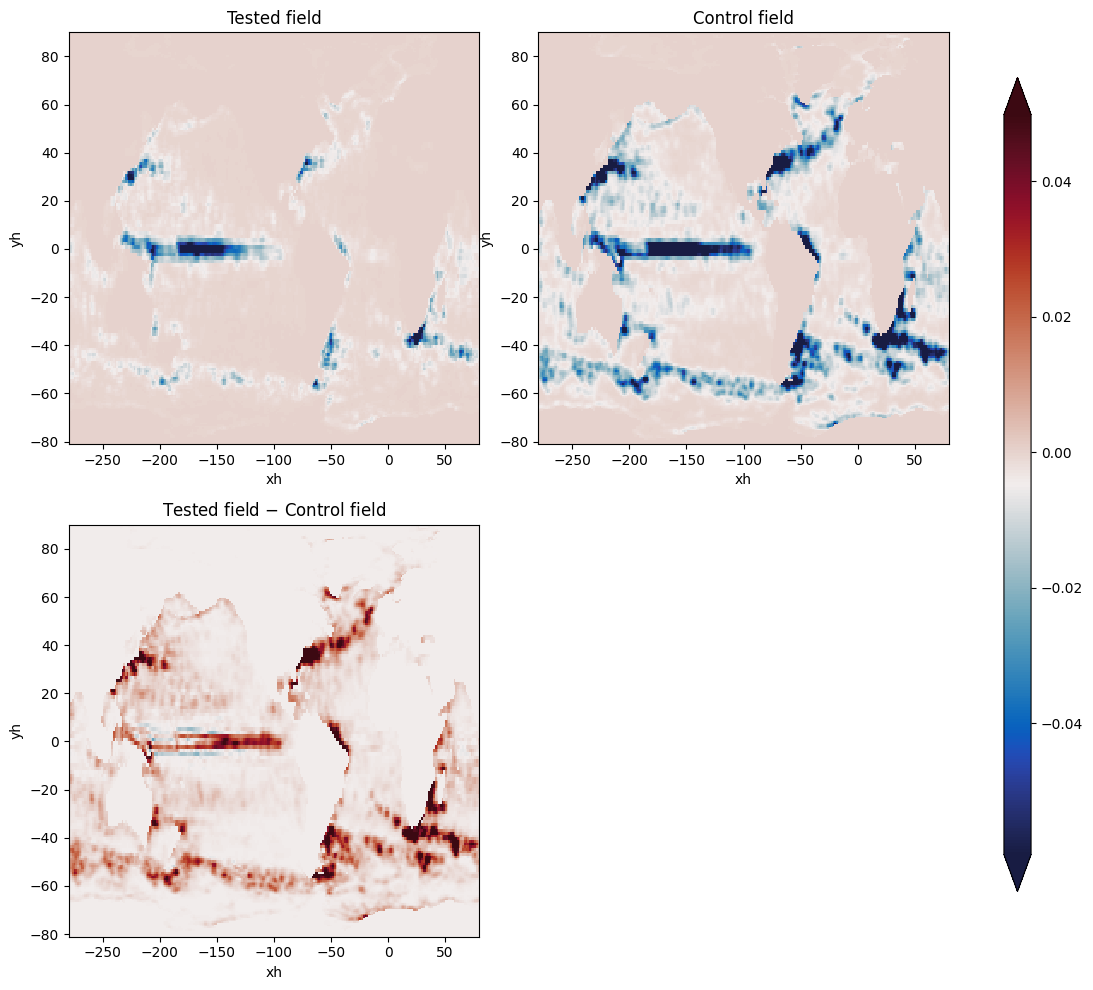

In [59]:
compare(skill.Txx_pred.isel(zl=3), skill.Txx.isel(zl=3),selector=select_globe);

Correlation: 0.7990368604660034
Relative Error: 0.7769725918769836
R2 =  0.4117443561553955
R2 max =  0.654117226600647
Optinal scaling: 2.5556836128234863
Nans [test/control]: [0, 0]


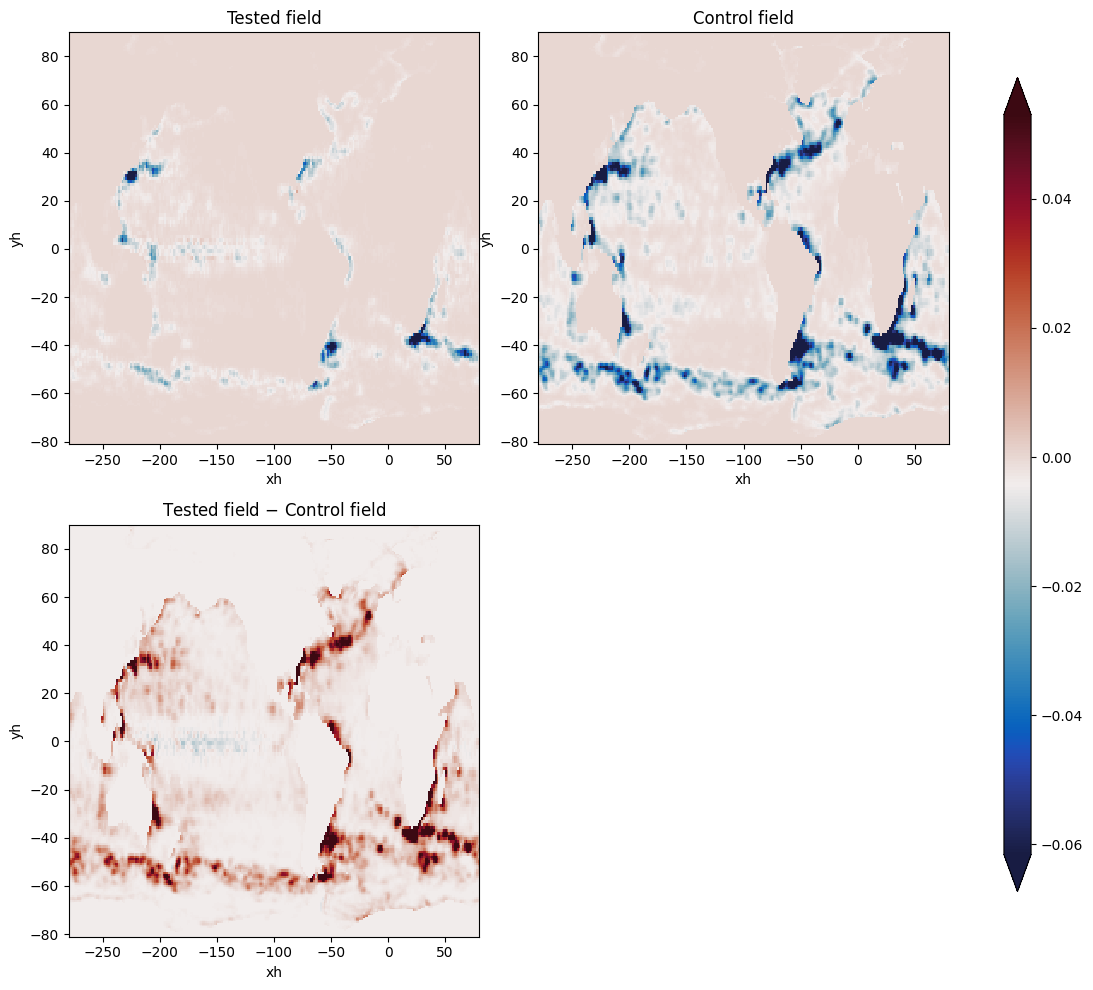

In [60]:
compare(skill.Tyy_pred.isel(zl=3), skill.Tyy.isel(zl=3),selector=select_globe);

Correlation: 0.6575344800949097
Relative Error: 0.8061777353286743
R2 =  0.39788663387298584
R2 max =  0.4323446750640869
Optinal scaling: 1.3933645486831665
Nans [test/control]: [0, 0]


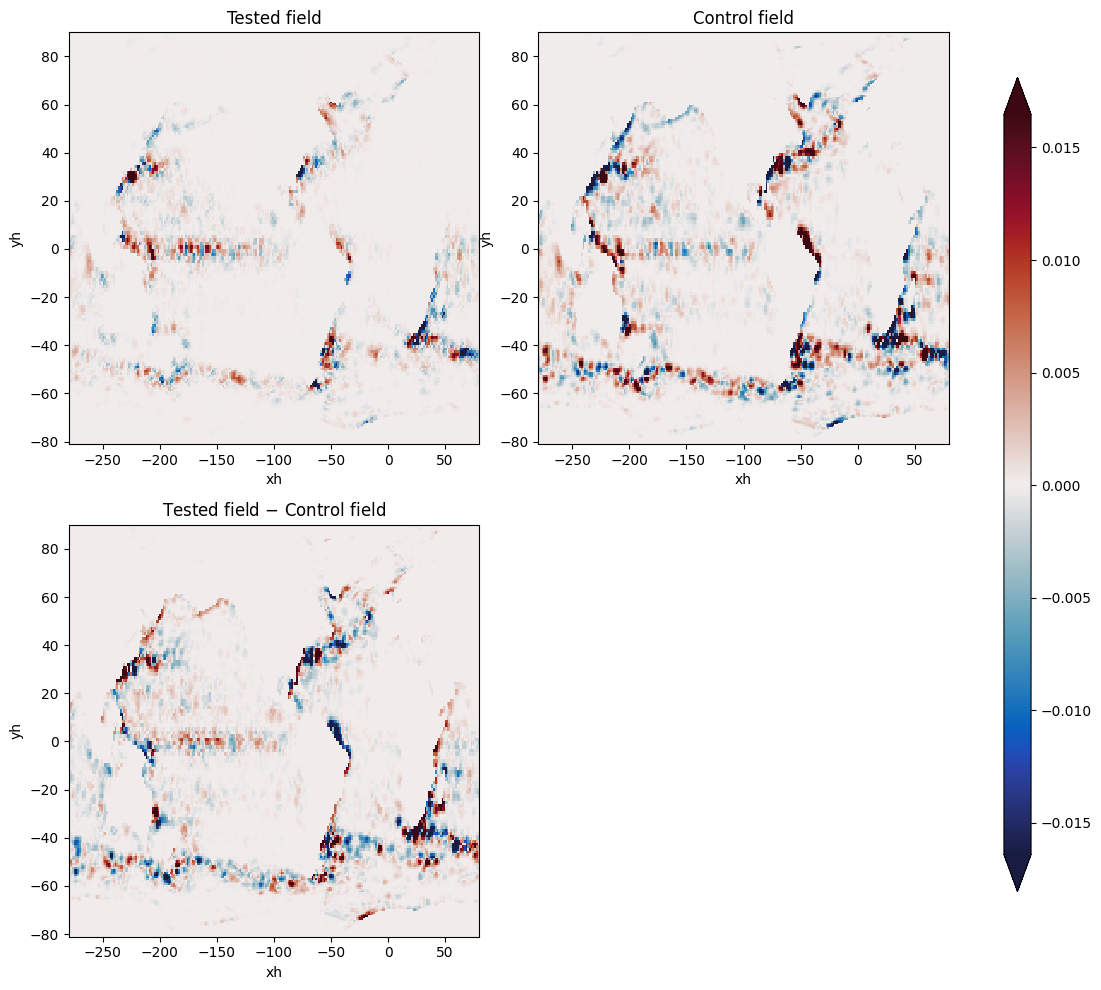

In [61]:
compare(skill.Txy_pred.isel(zl=3), skill.Txy.isel(zl=3),selector=select_globe);

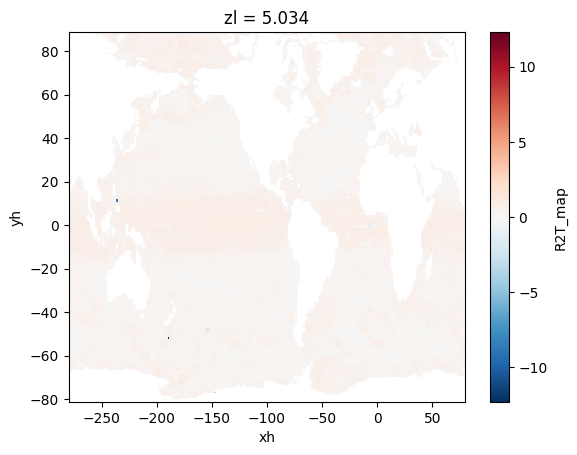

In [65]:
skill.R2T_map.isel(zl=0).isel(yh=slice(None,-2)).plot()

# Resolving Memory issue

In [29]:
ds = read_datasets(['validate'], [4], subfilter='subfilter-large', FGR=3)

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15


In [14]:
EXP1 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/EXP1/model/Tall.nc')

In [15]:
%time data = ds[f'validate-4'].predict_ANN(None, None, EXP1, stencil_size=3, dimensional_scaling=True, gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])

CPU times: user 4min 35s, sys: 49.5 s, total: 5min 25s
Wall time: 1min 37s


In [16]:
%time skill = data.SGS_skill()

CPU times: user 53.9 s, sys: 14.9 s, total: 1min 8s
Wall time: 52.7 s


In [17]:
del data

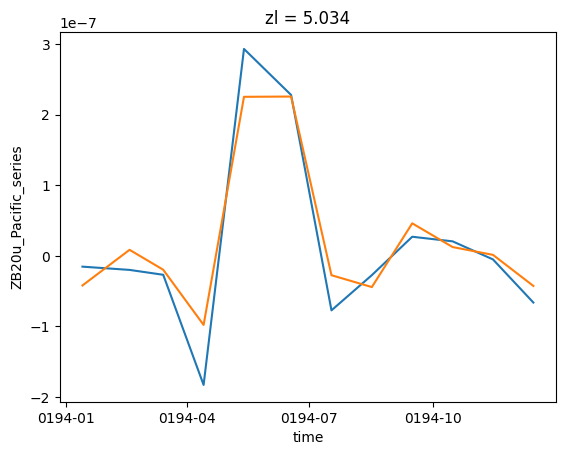

In [18]:
skill.SGSx_Pacific_series.isel(zl=0).plot()
skill.ZB20u_Pacific_series.isel(zl=0).plot()

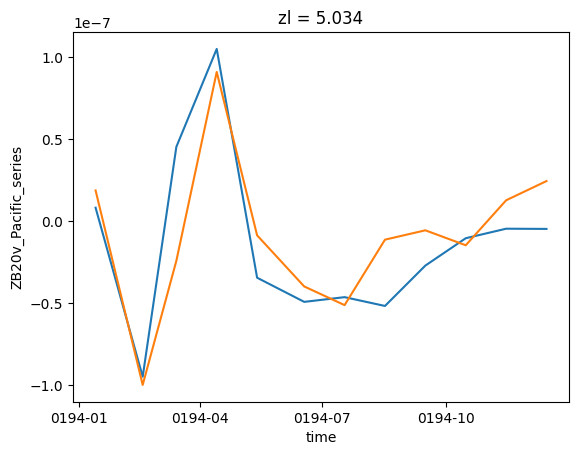

In [19]:
skill.SGSy_Pacific_series.isel(zl=0).plot()
skill.ZB20v_Pacific_series.isel(zl=0).plot()

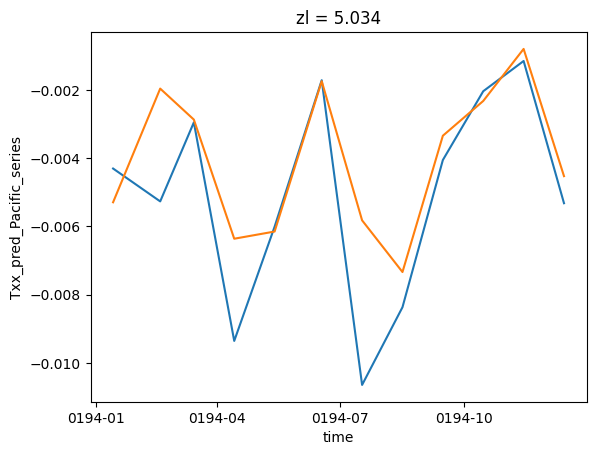

In [20]:
skill.Txx_Pacific_series.isel(zl=0).plot()
skill.Txx_pred_Pacific_series.isel(zl=0).plot()

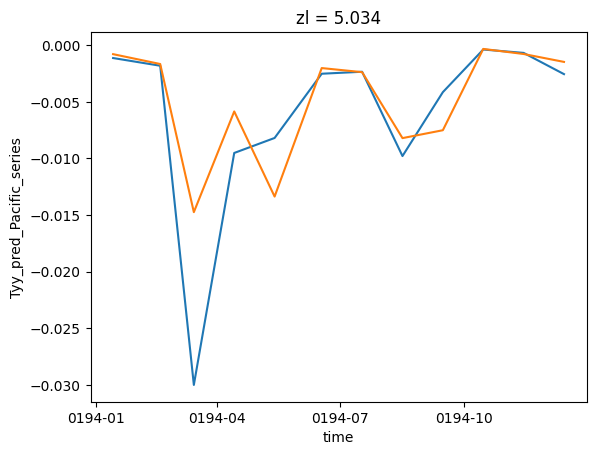

In [21]:
skill.Tyy_Pacific_series.isel(zl=0).plot()
skill.Tyy_pred_Pacific_series.isel(zl=0).plot()

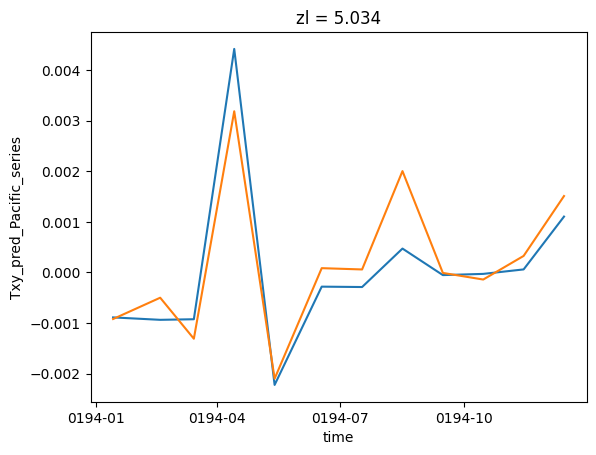

In [22]:
skill.Txy_Pacific_series.isel(zl=0).plot()
skill.Txy_pred_Pacific_series.isel(zl=0).plot()

# Memory leak

In [33]:
ds = read_datasets(['test'], [9], subfilter='subfilter-large', FGR=3)

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9


In [35]:
EXP1 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/EXP1/model/Tall.nc')
%time skill = ds[f'test-9'].predict_ANN(None, None, EXP1, stencil_size=3, dimensional_scaling=True, gradient_features=['sh_xy', 'sh_xx', 'rel_vort']).SGS_skill()

CPU times: user 4min 56s, sys: 18.7 s, total: 5min 15s
Wall time: 2min 5s


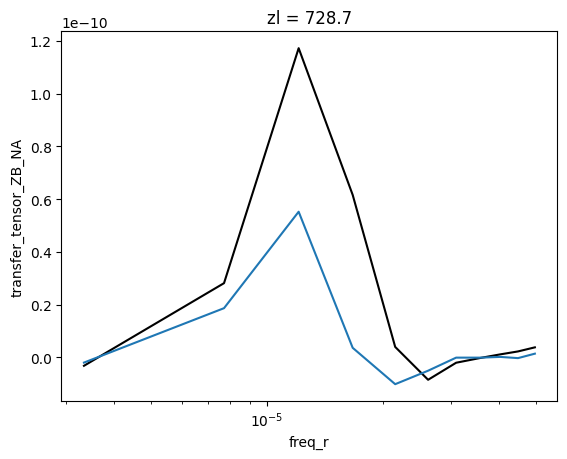

In [39]:
skill.transfer_tensor_NA.isel(zl=5).mean('time').plot(color='k')
skill.transfer_tensor_ZB_NA.isel(zl=5).mean('time').plot()
plt.xscale('log')

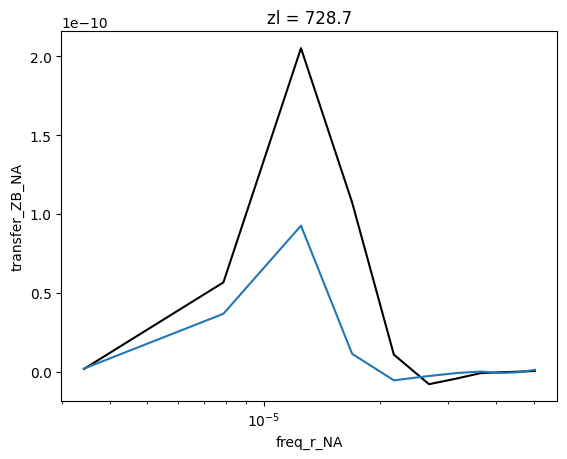

In [40]:
skill.transfer_NA.isel(zl=5).mean('time').plot(color='k')
skill.transfer_ZB_NA.isel(zl=5).mean('time').plot()
plt.xscale('log')

In [9]:
skill.to_netcdf('test.nc')

In [10]:
del skill

In [12]:
import gc
gc.collect()

1706

# Additional spectrum diagnostic

In [30]:
ds = read_datasets(['validate'], [4], subfilter='subfilter-large', FGR=3)['validate-4']

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4


In [31]:
spectrumT = ds.state.transfer_tensor(ds.data.Txy, ds.data.Txx, ds.data.Tyy).compute()
spectrumS = ds.state.transfer(ds.data.SGSx, ds.data.SGSy).compute()

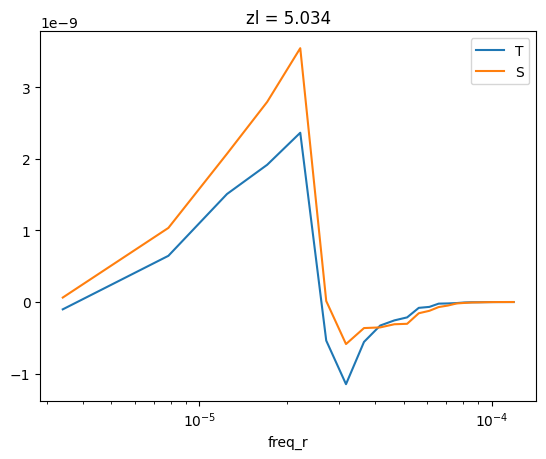

In [32]:
spectrumT.isel(zl=0).mean('time').plot(label='T')
spectrumS.isel(zl=0).mean('time').plot(label='S')
plt.xscale('log')
plt.legend()

# Check trained model

In [2]:
ds = xr.open_dataset('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter-large/FGR3/EXP0/skill-test/factor-15.nc')

Correlation: 0.5947965979576111
Relative Error: 0.7598378658294678
R2 =  0.31774193048477173
R2 max =  0.4802476763725281
Optinal scaling: 2.3906493186950684
Nans [test/control]: [0, 0]


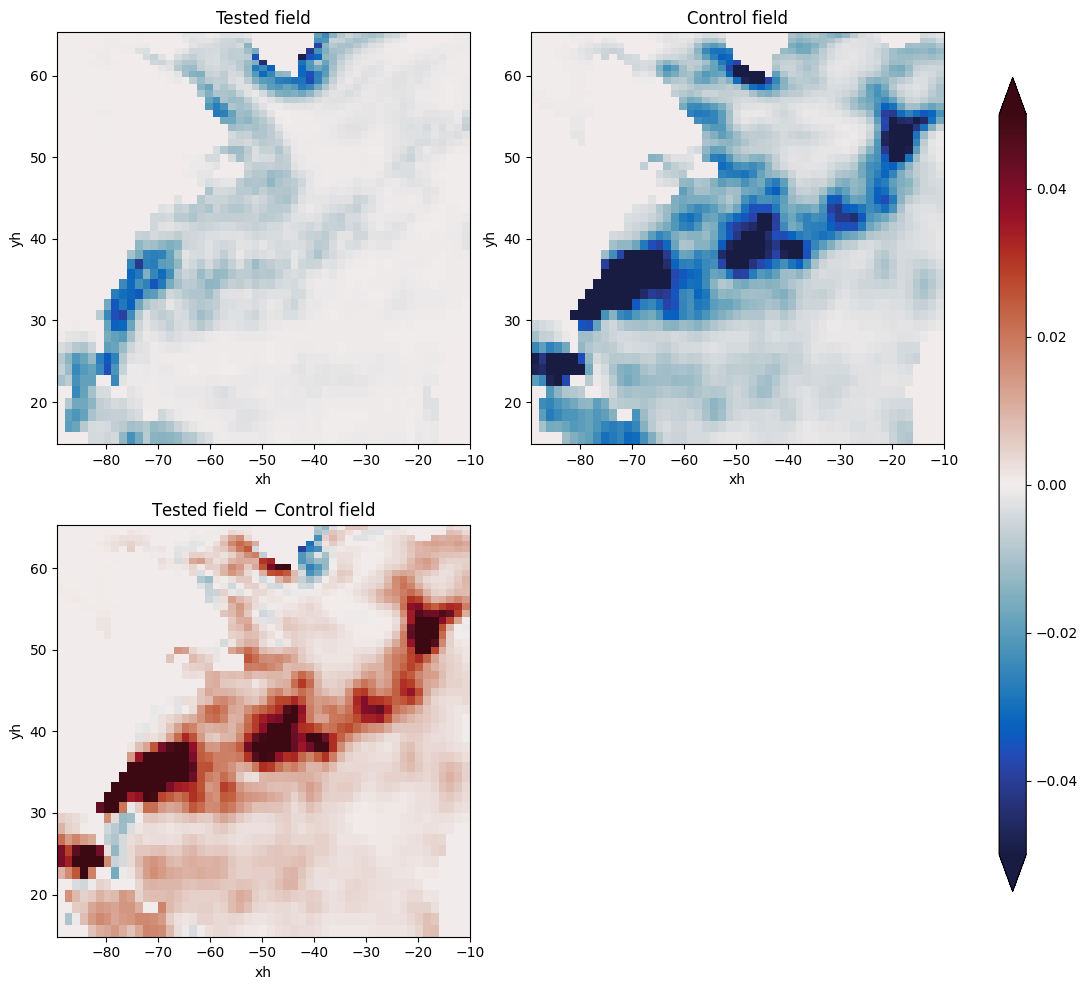

In [3]:
compare(ds.Txx_pred.isel(zl=0), ds.Txx.isel(zl=0), vmin=-0.05, vmax=0.05);

Correlation: 0.10876214504241943
Relative Error: 1.1551815271377563
R2 =  -0.20676934719085693
R2 max =  0.012391805648803711
Optinal scaling: 0.19210565090179443
Nans [test/control]: [0, 0]


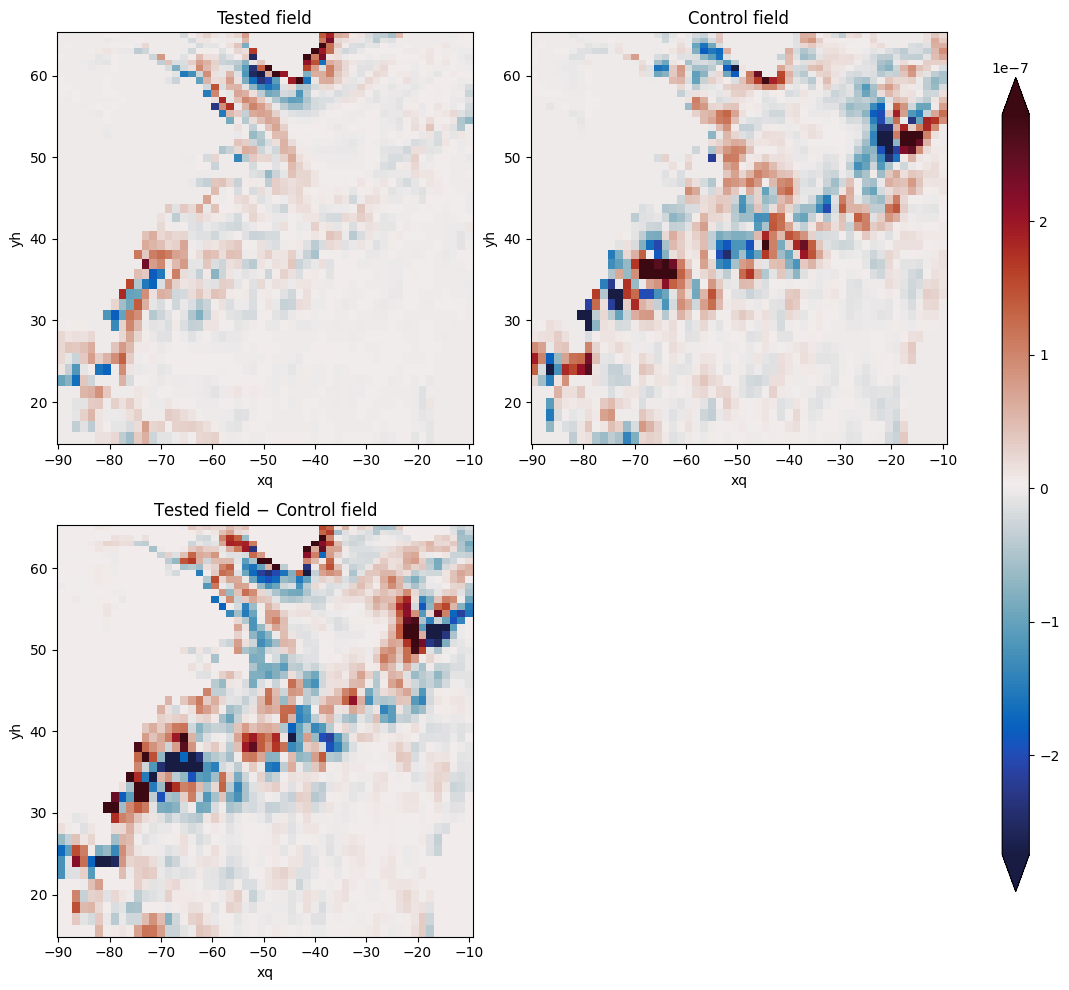

In [4]:
compare(ds.ZB20u.isel(zl=0), ds.SGSx.isel(zl=0));

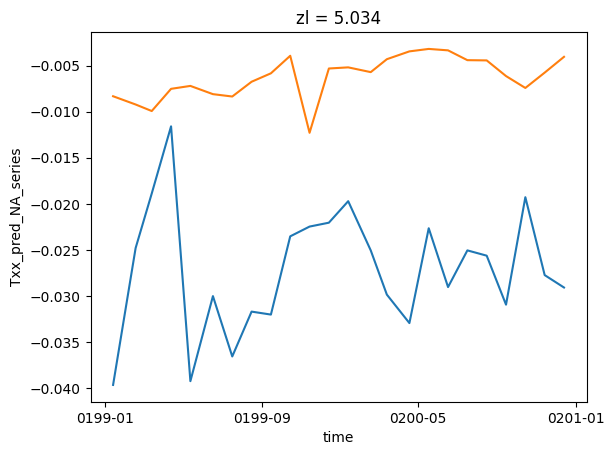

In [5]:
ds.Txx_NA_series.isel(zl=0).plot()
ds.Txx_pred_NA_series.isel(zl=0).plot()

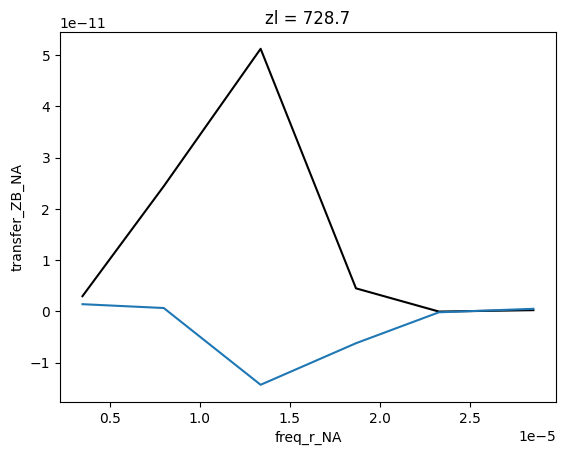

In [6]:
ds.transfer_NA.isel(zl=5).mean('time').plot(color='k')
ds.transfer_ZB_NA.isel(zl=5).mean('time').plot()